# Hermitian and non-Hermitian mean-field calculations

`get_mean_field_hamiltonian` works identically whether the underlying single-particle Hamiltonian is
Hermitian or not: a Hamiltonian built with `non_hermitian=True` (e.g. with gain/loss onsite terms)
carries a `non_hermitian` flag that simply skips the Hermiticity sanity-check the SCF loop otherwise
runs every iteration, and the same Hartree-Fock machinery converges an interacting mean field on top
of it. The ordinary Hermitian case has a real spectrum; the non-Hermitian case develops complex
energies.

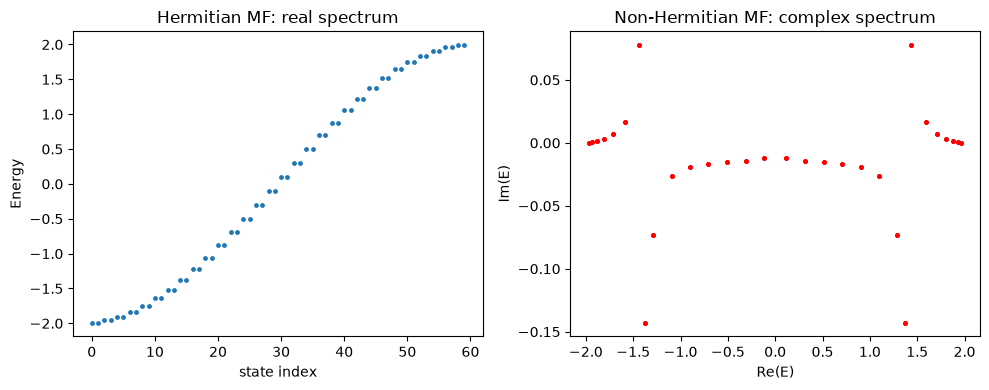

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import check

# Hermitian case
g = geometry.chain(30) ; g.dimensionality = 0
h = g.get_hamiltonian(has_spin=True)
h = h.get_mean_field_hamiltonian(U=1.5,filling=0.5,mf="ferro")
check.check_hamiltonian(h) # raises if not actually Hermitian
(_,e_herm) = h.get_bands()

# non-Hermitian case: onsite gain/loss on top of the same chain
g2 = geometry.chain(30) ; g2.dimensionality = 0
h2 = g2.get_hamiltonian(has_spin=True,non_hermitian=True)
h2.add_onsite(lambda r: 1j*0.3*np.cos(2*np.pi*0.25*r[0]))
h2 = h2.get_mean_field_hamiltonian(U=1.5,filling=0.5,mf="ferro")
(_,e_nonherm) = h2.get_bands()

fig,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].scatter(range(len(e_herm)),np.real(e_herm),s=6)
axs[0].set_title("Hermitian MF: real spectrum")
axs[0].set_xlabel("state index") ; axs[0].set_ylabel("Energy")
axs[1].scatter(np.real(e_nonherm),np.imag(e_nonherm),s=6,c="red")
axs[1].set_title("Non-Hermitian MF: complex spectrum")
axs[1].set_xlabel("Re(E)") ; axs[1].set_ylabel("Im(E)")
plt.tight_layout()
plt.show()